**Prédiction du défaut de remboursement d'un prêt immobilier (mortgage)**

****Ce dataset concerne des prêts immobiliers (mortgage) et vise à prédire si un emprunteur sera en défaut de paiement. Il contient une combinaison de variables démographiques, financières et contractuelles**** /n

Taille : 148 670 lignes

## Analyse exploratoire des données (EDA)

****Import des librairies utilisées****

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest,mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import ExtraTreesClassifier, AdaBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
import joblib

In [2]:
#Lecture du dataset
df=pd.read_csv("C:/Users/souri/Desktop/PYTHON/ML/Projet/Loan_Default.csv")

In [3]:
#affichage
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [3]:
df.columns

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='object')

In [4]:
df.shape

(148670, 34)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

**La base de données comprend 148670 lignes (observations) et 34 variables.**

***Compréhension des variables:***

****Description des données à partir de Kaggle:****

https://www.kaggle.com/datasets/yasserh/loan-default-dataset/discussion/522084

**ID:**	client loan application id

**year:** year of loan application

**loan_limit:**	indicates whether the loan is conforming (cf) or non-conforming (ncf)

**Gender:**	gender of the applicant (male, female, joint, sex not available)

**approv_in_adv:** indicates whether the loan was approved in advance (pre, nopre)

**loan_type:** type of loan (type1, type2, type3)

**loan_purpose:** purpose of the loan (p1, p2, p3, p4)

**Credit_Worthiness:**	credit worthiness (l1, l2)

**open_credit:** indicates whether the applicant has any open credit accounts (opc, nopc)

**business_or_commercial:**	indicates whether the loan is for business/commercial purposes (ob/c - business/commercial, nob/c - personal)

**loan_amount:** amount of money being borrowed

**rate_of_interest:** interest rate charged on the loan

**Interest_rate_spread:** difference between the interest rate on the loan and a benchmark interest rate

**Upfront_charges:** initial charges associated with securing the loan term duration of the loan in months

**Neg_ammortization:**	indicates whether the loan allows for negative ammortization (neg_amm, not_neg)

**interest_only:**	indicates whether the loan has an interest-only payment option (int_only, not_int)

**lump_sum_payment:** indicates if a lump sum payment is required at the end of the loan term (lpsm, not_lpsm)

**property_value:**	value of the property being financed

**construction_type:**	type of construction (sb - site built, mh - manufactured home)

**occupancy_type:**	occupancy type (pr - primary residence, sr- secondary residence, ir - investment property)

**Secured_by:**	specifies the type of collateral securing the loan (home, land)

**total_units:**	number of units in the property being financed (1U, 2U, 3U, 4U)

**income:** applicant's annual income

**credit_type:** applicant's type of credit (CIB - credit information bureau , CRIF - CIRF credit information bureau, EXP - experian , EQUI - equifax)

**Credit_Score:** applicant's credit score

**co-applicant_credit_type:** co-applicant's type of credit (CIB - credit information bureau EXP - experian)

**age:** the age of the applicant.

**submission_of_application:**	indicates how the application was submitted (to_inst - to institution, not_inst - not to institution)

**LTV:**	loan-to-value ratio, calculated as the loan amount divided by the property value

**Region:** geographic region where the property is located (North, south, central, North-East)

**Security_Type:**	type of security or collateral backing the loan (direct, indirect)

**Status:**	indicates whether the loan has been defaulted (1) or not (0)

**dtir1:**	debt-to-income ratio

## Spécification de la variable Target

In [11]:
print(df['Status'].value_counts())
print(df['Status'].value_counts(normalize=True).round(3) * 100)

Status
0    112031
1     36639
Name: count, dtype: int64
Status
0    75.4
1    24.6
Name: proportion, dtype: float64


<Axes: xlabel='Status', ylabel='count'>

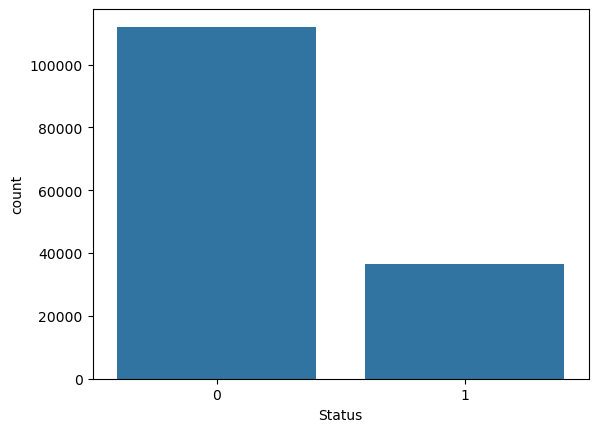

In [13]:
sns.countplot(x='Status', data=df)

La variable Cible est "**Status**"; qui est le paramtére indiquant si le crédit est en défaut Status=1 ou non Status=0

- **0** : remboursement normal (112 031 cas, 75.4%)
- **1** : défaut de paiement (36 639 cas, 24.6%)

Le dataset présente un déséquilibre modéré entre les classes. Ce déséquilibre devra être pris en compte lors du preprocessing.

In [5]:
df['year'].unique()

array([2019])

****La colonne year ne contient qu’une seule valeur (2019). Elle peut donc être supprimée de l’analyse, car elle n’apporte pas d’information pertinente.****

****De même, la colonne ID peut être supprimée, car elle n’apporte pas d’information utile pour la variable cible "Status"****

In [11]:
df.isna().sum()

ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_applic

****Les colonnes: loan_limit, approv_in_adv, loan_purpose, rate_of_interest, Interest_rate_spread, Upfront_charges, term,Neg_ammortization, property_value,income,age, submission_of_application, LTV et  dtir1  comprennent des valeurs manquantes****

In [13]:
#pourcentage:
((df.isna().sum() / 148670) * 100).round(2)

ID                            0.00
year                          0.00
loan_limit                    2.25
Gender                        0.00
approv_in_adv                 0.61
loan_type                     0.00
loan_purpose                  0.09
Credit_Worthiness             0.00
open_credit                   0.00
business_or_commercial        0.00
loan_amount                   0.00
rate_of_interest             24.51
Interest_rate_spread         24.64
Upfront_charges              26.66
term                          0.03
Neg_ammortization             0.08
interest_only                 0.00
lump_sum_payment              0.00
property_value               10.16
construction_type             0.00
occupancy_type                0.00
Secured_by                    0.00
total_units                   0.00
income                        6.15
credit_type                   0.00
Credit_Score                  0.00
co-applicant_credit_type      0.00
age                           0.13
submission_of_applic

In [4]:
missing = ((df.isna().sum() / 148670) * 100).round(2)
missing = missing[missing > 0].sort_values(ascending=False)

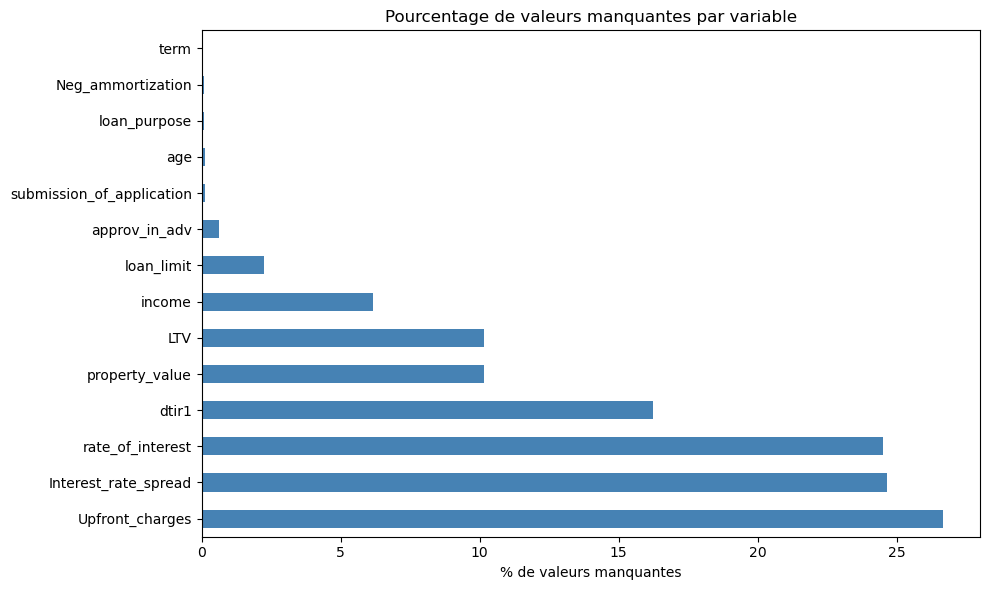

In [5]:
missing.plot(kind='barh', figsize=(10, 6), color='steelblue')
plt.title('Pourcentage de valeurs manquantes par variable')
plt.xlabel('% de valeurs manquantes')
plt.tight_layout()
plt.show()

Selon les pourcentages, trois groupes se distinguent:

**-Upfront_charges, Interest_rate_spread et rate_of_interest:** environ 25%

**-dtir1, property_value et LTV:** entre 10% et 16%

**-Les autres variables:** moins de 3%

In [18]:
df[df['Interest_rate_spread'].isna()]['Status'].unique()

array([1])

In [19]:
df[df['Status']==1]['Interest_rate_spread'].unique()

array([nan])

Interest_rate_spread est NaN exactement quand il y a défaut (Status=1).

La variable **Interest_rate_spread** présente un data leakage; les valeurs manquantes coïncident parfaitement avec les cas de défaut (Status=1). 

La garder introduirait un biais dans le modèle. Elle sera donc supprimée lors du preprocessing

In [20]:
df[df['rate_of_interest'].isna()]['Status'].unique()

array([1])

In [21]:
df[df['Status']==1]['rate_of_interest'].unique()

array([  nan, 3.75 , 4.625, 4.5  , 3.875, 4.375, 4.75 , 4.99 , 4.25 ,
       3.99 , 4.875, 5.375, 4.125, 5.25 , 5.125, 4.49 , 4.865, 5.   ,
       3.5  , 3.375, 4.   , 5.5  , 3.625, 3.125])

In [22]:
df[df['Upfront_charges'].isna()]['Status'].unique()

array([1, 0])

-***Upfront_charges*** a des NaN dans les deux cas (défaut et non-défaut) (à imputer lors du preprocessing)

-Les NaN de ***rate_of_interest*** sont présents uniquement chez Status=1, une imputation ciblée sera nécessaire lors du preprocessing.

In [7]:
mask = (df.isna().sum() / 148670) * 100
for col in df.columns[(mask > 0) & (mask < 24)]:
    print(col, df[df[col].isna()]['Status'].unique())

loan_limit [0 1]
approv_in_adv [0 1]
loan_purpose [0 1]
term [1 0]
Neg_ammortization [0 1]
property_value [1 0]
income [0 1]
age [1]
submission_of_application [1]
LTV [1 0]
dtir1 [1 0]


In [34]:
#Vérifier le cas inverse entre age et Status:
df[df['Status']==1]['age'].unique()

array(['25-34', '55-64', '65-74', '45-54', '35-44', '<25', '>74', nan],
      dtype=object)

In [35]:
df[df['Status']==1]['submission_of_application'].unique()

array(['to_inst', 'not_inst', nan], dtype=object)

## Conclusions:Valeurs Manquantes:

.Data leakage parfait (à supprimer): Interest_rate_spread

.Data leakage partiel (imputation ciblée pour "Status" = 1): rate_of_interest, age, submission_of_application  

.Valeurs manquantes aléatoires: Upfront_charges, dtir1, property_value, LTV, income, loan_limit, approv_in_adv, loan_purpose, term, Neg_ammortization

## Distribution et Outliers:

In [9]:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


LTV présente une valeur maximale très élevée (7831%), ce qui est suspect et peut indiquer des anomalies ou des outliers.

Les variables *income*, *property_value* et *loan_amount* présentent également une forte dispersion des valeurs.

In [39]:
df.select_dtypes(include='number').columns

Index(['ID', 'year', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread',
       'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score',
       'LTV', 'Status', 'dtir1'],
      dtype='object')

ID, year seront exclut de l'analyse, Statuts aussi puisque c'est notre varibales cibles.

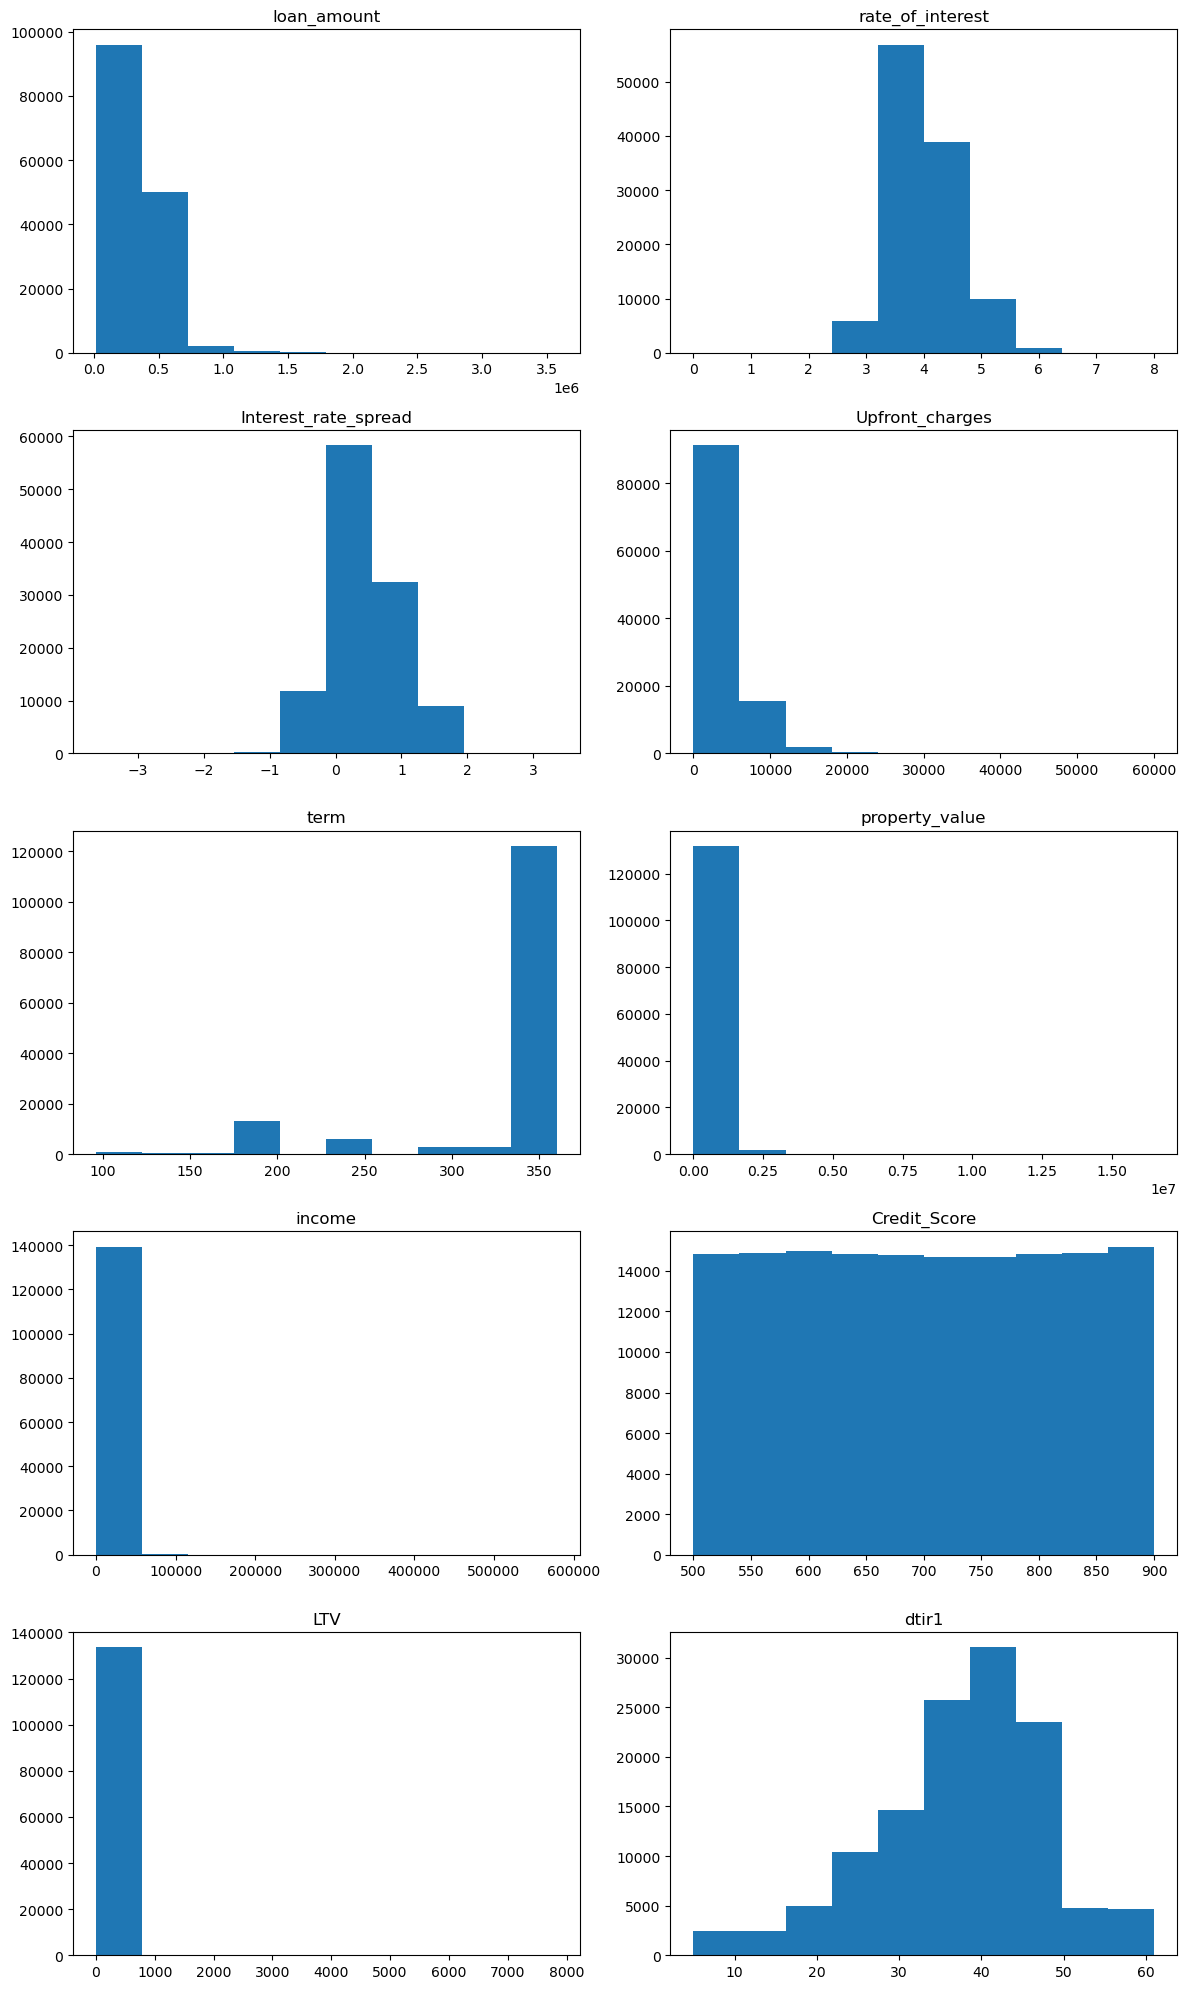

In [8]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 20))
axes = axes.flatten()

columns=['loan_amount', 'rate_of_interest', 'Interest_rate_spread',
       'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score',
       'LTV', 'dtir1']
for i, col in enumerate(columns):
    axes[i].hist(df[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

**Analyse des distributions**

- *loan_amount*, *income*, *property_value* : distributions asymétriques à droite (skewed), avec une concentration des valeurs sur les faibles montants et quelques valeurs élevées.

- *rate_of_interest* : distribution proche de la normale, centrée autour de 4%.

- *dtir1* : distribution globalement symétrique et relativement proche d’une loi normale.

- *LTV* : forte concentration des valeurs vers la gauche, avec la présence de valeurs extrêmes qui écrasent la visualisation.

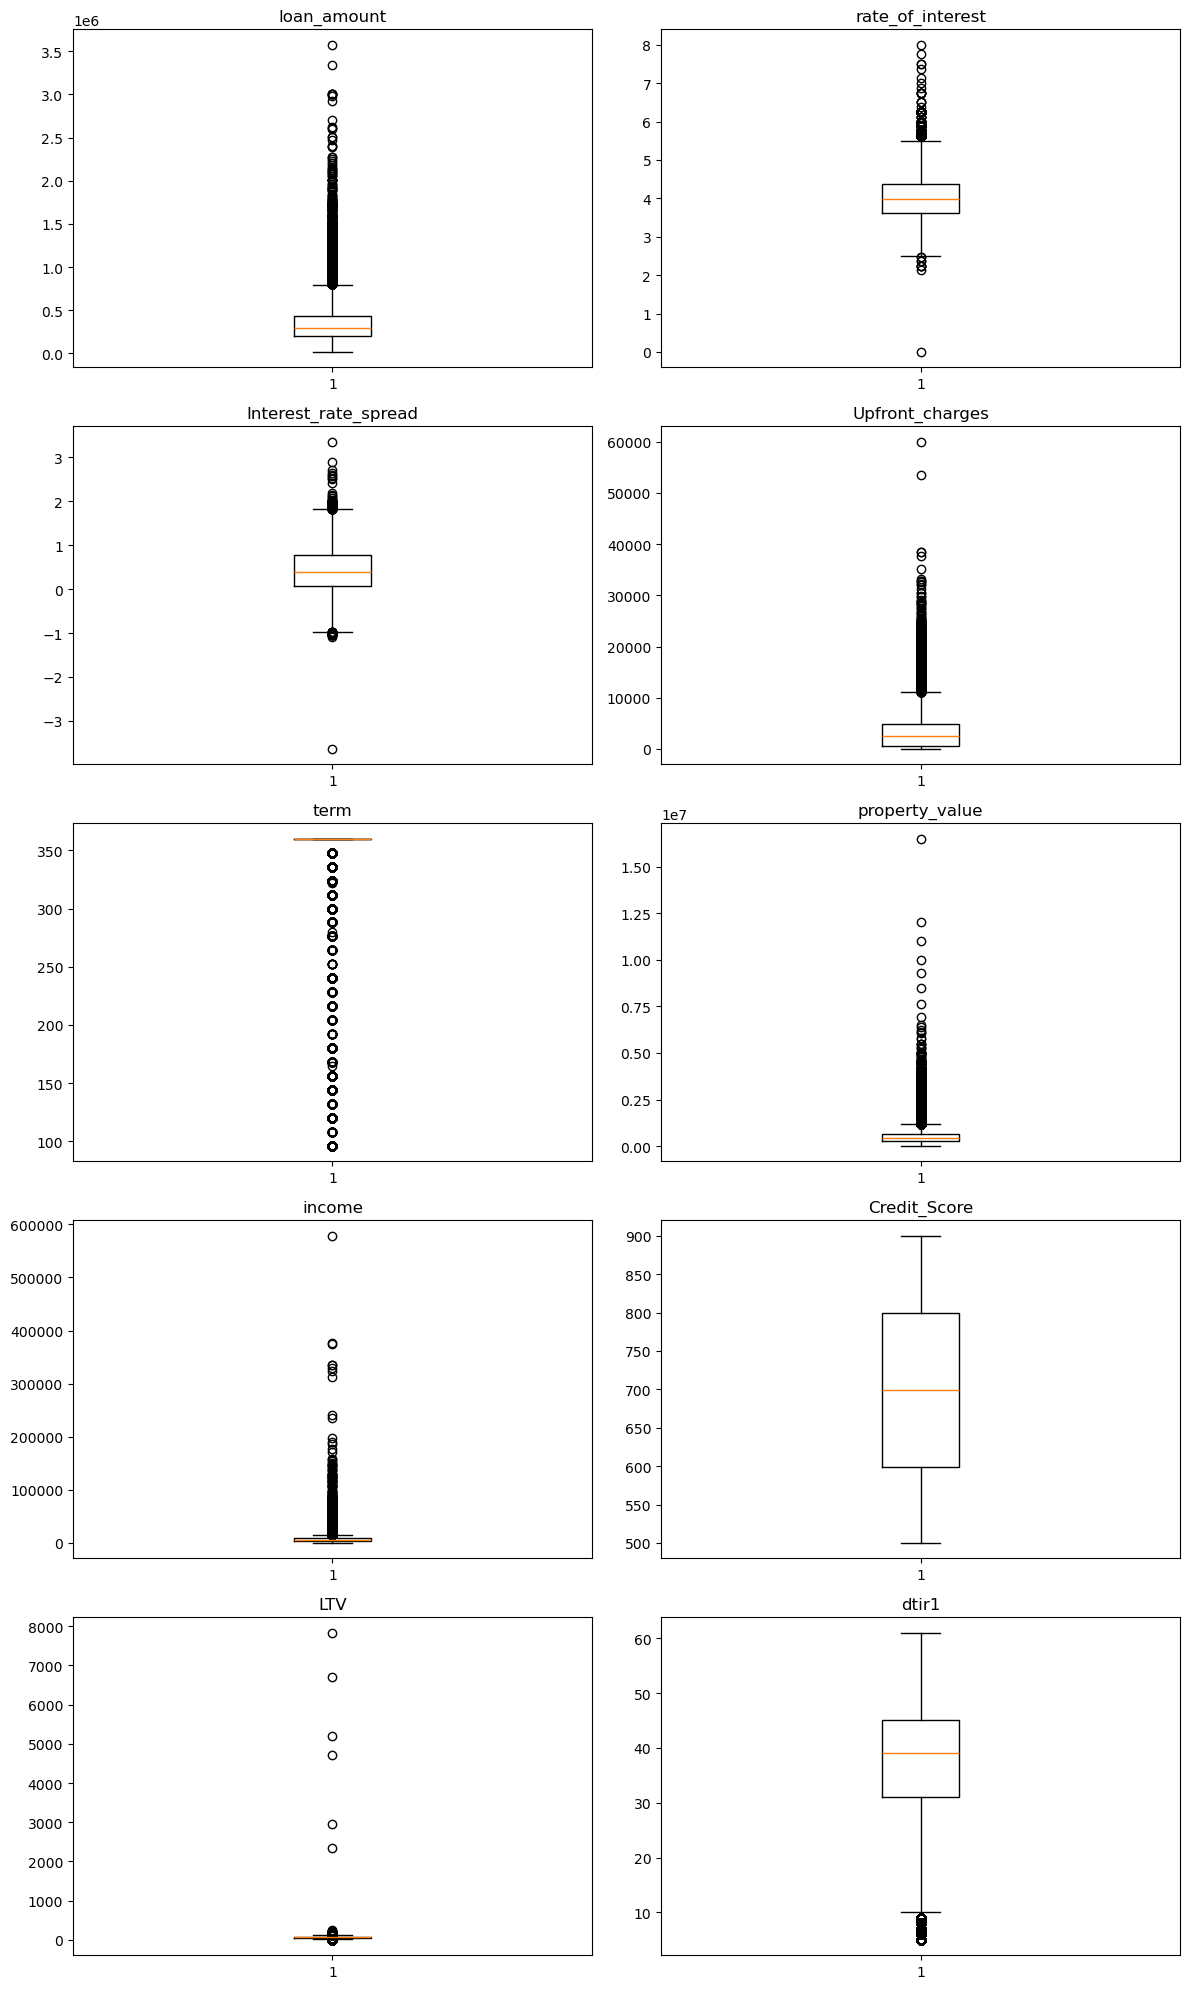

In [9]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 20))
axes = axes.flatten()

columns=['loan_amount', 'rate_of_interest', 'Interest_rate_spread',
       'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score',
       'LTV', 'dtir1']
for i, col in enumerate(columns):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

 **Analyse des outliers:**

- *LTV* : présence de véritables outliers à traiter, avec une valeur maximale de 7831% considérée comme incohérente.

- *loan_amount*, *property_value*, *income* : ces variables présentent également des valeurs extrêmes, mais celles-ci restent globalement cohérentes d’un point de vue métier et peuvent être considérées comme plausibles.

- *term*, *Credit_Score* : distributions globalement normales, sans outliers problématiques identifiés.

-  *dtir1*, *rate_of_interest*, *Upfront_charges*: valeurs extrêmes observées mais considérées comme légitimes d’un point de vue métier, car elles restent cohérentes avec la réalité des données financières.

## Analyse Bivariée: Variables Catégorielles

In [47]:
df.groupby('Gender')['Status'].mean()

Gender
Female               0.251155
Joint                0.191623
Male                 0.261914
Sex Not Available    0.285908
Name: Status, dtype: float64

In [48]:
df.select_dtypes(include='object').columns

Index(['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose',
       'Credit_Worthiness', 'open_credit', 'business_or_commercial',
       'Neg_ammortization', 'interest_only', 'lump_sum_payment',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'credit_type', 'co-applicant_credit_type', 'age',
       'submission_of_application', 'Region', 'Security_Type'],
      dtype='object')

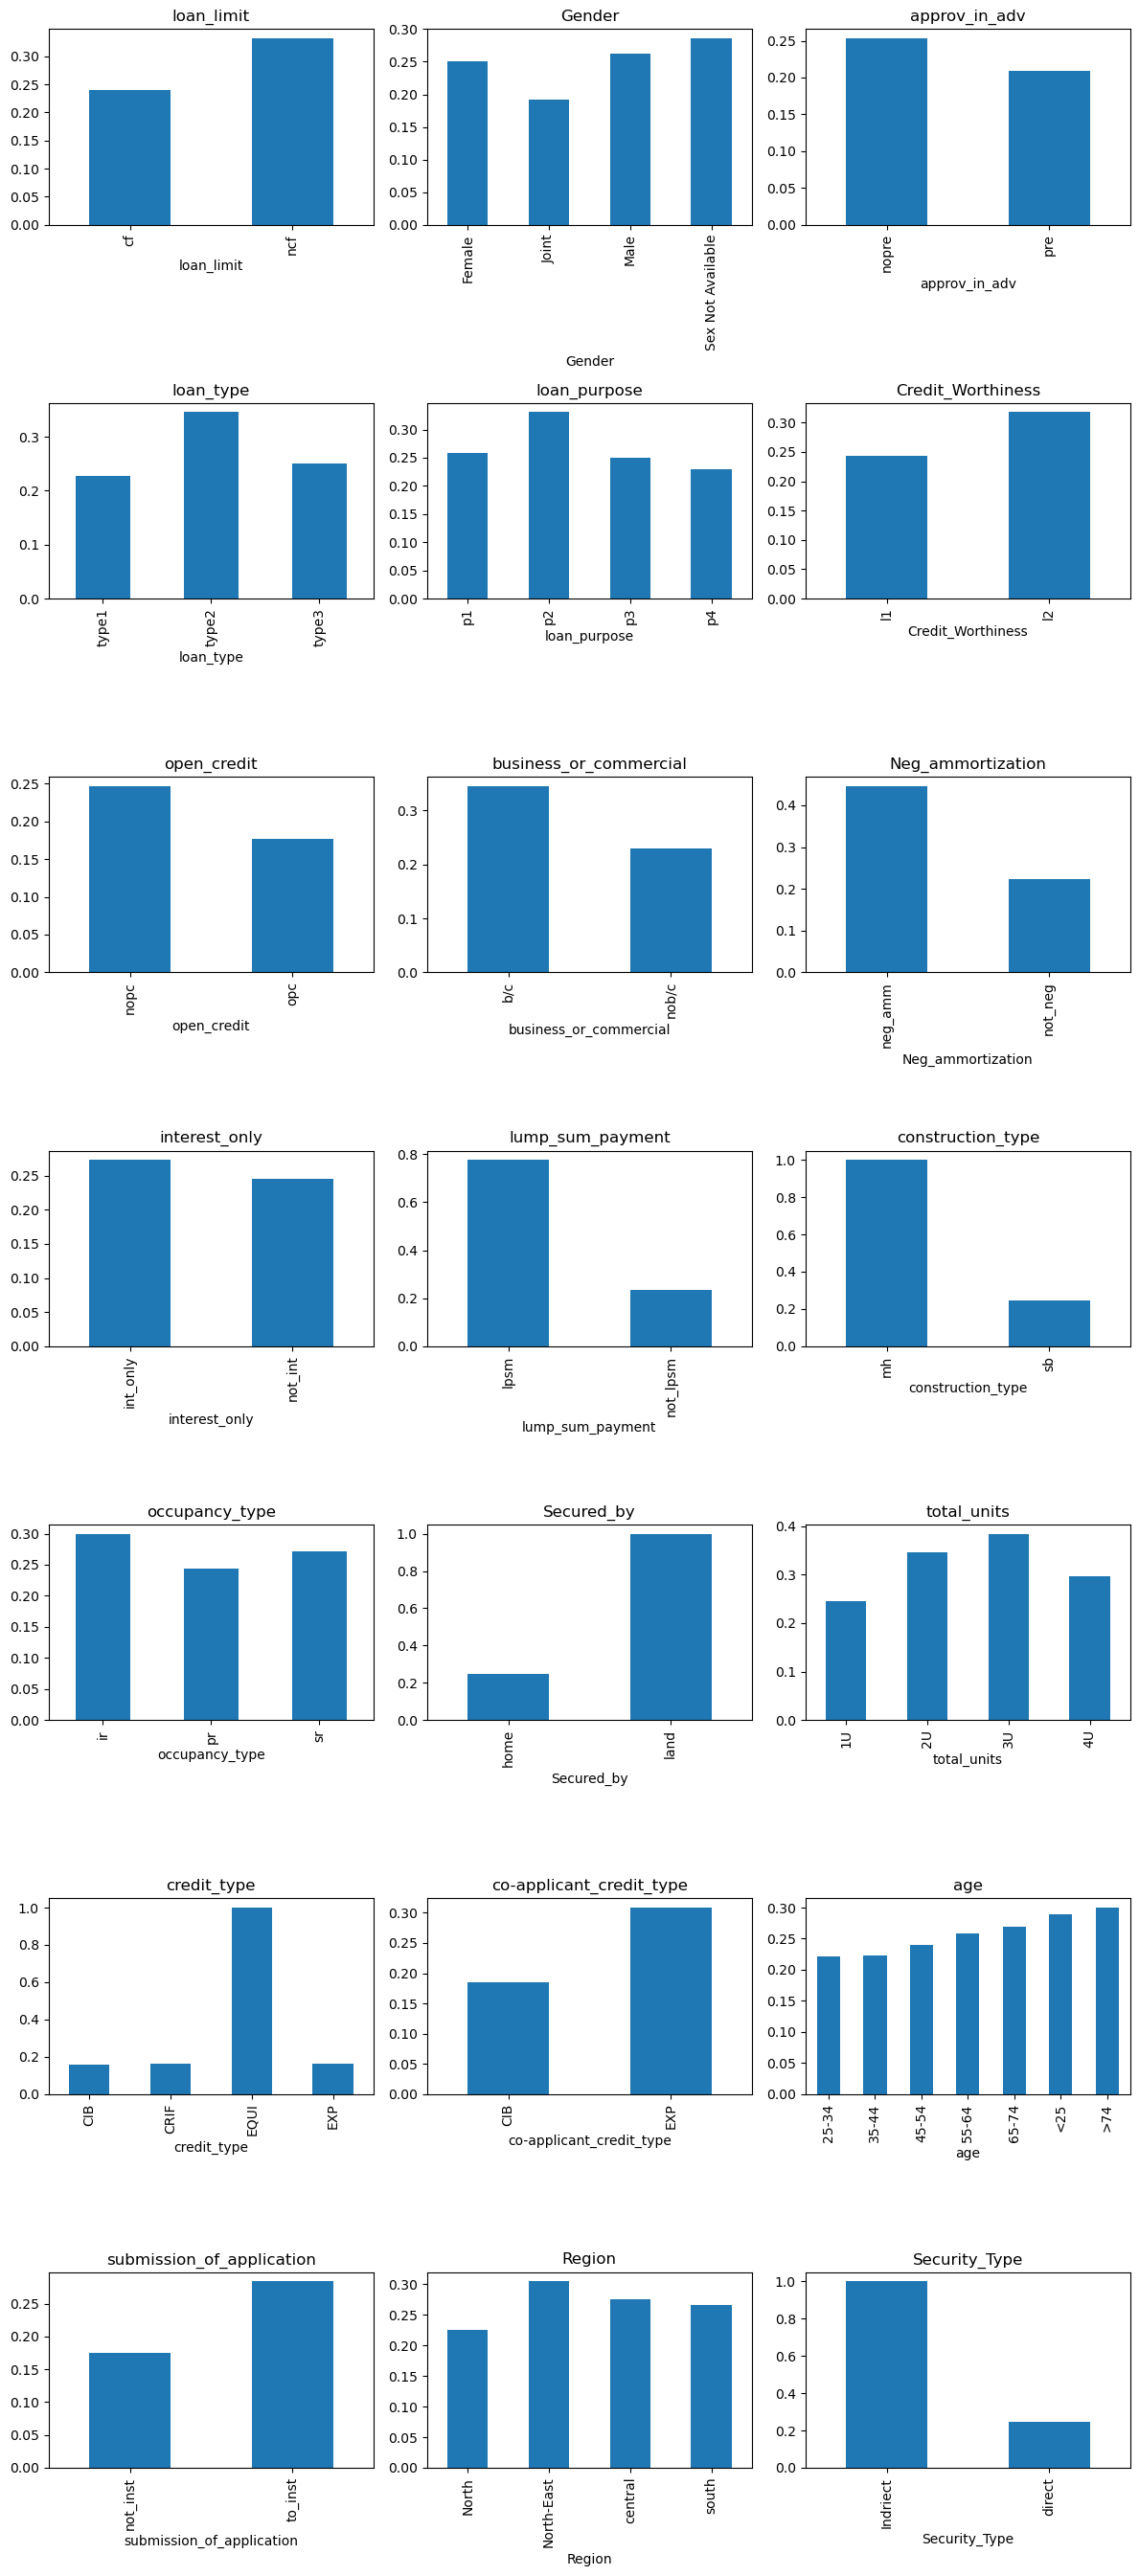

In [10]:
fig, axes = plt.subplots(nrows=7, ncols=3, figsize=(12, 27))
axes = axes.flatten()

columns=['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose',
       'Credit_Worthiness', 'open_credit', 'business_or_commercial',
       'Neg_ammortization', 'interest_only', 'lump_sum_payment',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'credit_type', 'co-applicant_credit_type', 'age',
       'submission_of_application', 'Region', 'Security_Type']
for i, col in enumerate(columns):
    df.groupby(col)['Status'].mean().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

## Conclusion: 

- **loan_limit** : les prêts non-conformes (ncf) présentent un taux de défaut plus élevé.
  
- **Gender** : les dossiers sans information sur le genre présentent un taux de défaut plus élevé.
 
- **approv_in_adv** : les prêts non pré-approuvés (nopre) présentent un taux de défaut plus élevé.
  
- **loan_type** : le type 2 présente un taux de défaut plus élevé.
 
- **loan_purpose** : la finalité P2 présente un taux de défaut plus élevé.
  
- **Credit_Worthiness** : le niveau L2 présente un taux de défaut plus élevé.
 
- **open_credit** : l'absence de crédit ouvert (nopc) est associée à plus de défauts.
  
- **business_or_commercial** : les prêts à usage commercial (b/c) présentent plus de défauts.
 
- **interest_only** : les prêts remboursés en intérêts uniquement présentent plus de défauts.
  
- **lump_sum_payment** : les prêts avec paiement forfaitaire (lpsm) présentent plus de défauts.
 
- **age** : les tranches d'âge extrêmes (moins de 25 ans et plus de 74 ans) présentent les taux de défaut les plus élevés, revenus instables pour les jeunes et fixes pour les retraités.
  
- **Region** : la région North-East présente le taux de défaut le plus élevé.

- **Neg_ammortization** : l'amortissement négatif est associé à un taux de défaut plus élevé, le capital augmente au lieu de diminuer, ce qui accroît le risque.
 
- **construction_type** : les manufactured homes (mh) présentent plus de défauts, bien de moindre valeur et moins stable comme garantie.
  
- **occupancy_type** : les résidences d'investissement (ir) présentent plus de défauts; dépendance aux revenus locatifs.
  
- **Secured_by** : les prêts garantis par un terrain (land) présentent plus de défauts; terrain moins liquide et plus difficile à revendre.

- **total_units** : les biens de 3 unités (3U) présentent plus de défauts.

- **credit_type** : le bureau EQUI est associé à plus de défauts.

- **co-applicant_credit_type** : le bureau EXP pour le co-emprunteur est associé à plus de défauts.

- **submission_of_application** : les demandes soumises via une institution (to_inst) présentent plus de défauts; dossiers parfois moins bien vérifiés.

## Corrélation:

<Axes: >

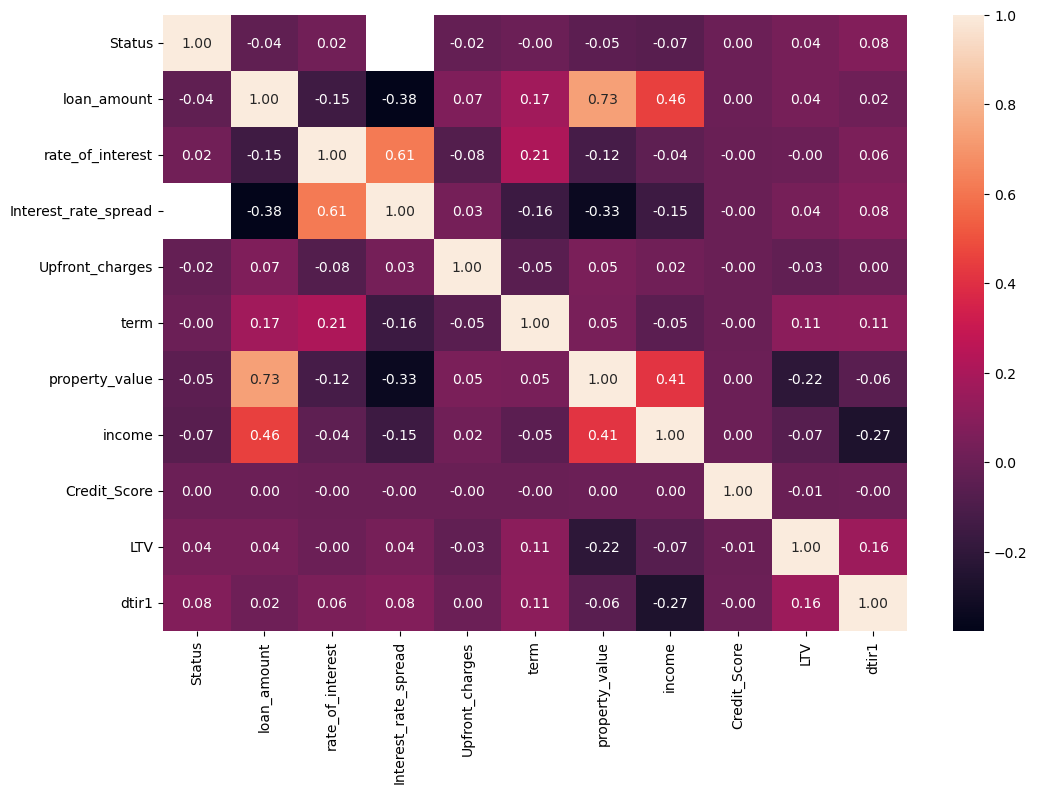

In [16]:
columns=['Status','loan_amount', 'rate_of_interest', 'Interest_rate_spread',
       'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score',
       'LTV', 'dtir1']
plt.figure(figsize=(12, 8))
correlation_matrix = df[columns].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f')

-Les corrélations avec **Status** sont toutes faibles (max -0.07 pour income).

-Les variables numériques seules ne suffisent pas à prédire le défaut, les variables catégorielles sont probablement plus importantes, d'après l'analyse bivariée.

- Une forte corrélation est observée entre *loan_amount* et *property_value* (0,73), ce qui peut indiquer un risque de multicolinéarité.

- *rate_of_interest* et *Interest_rate_spread* présentent également une corrélation élevée (0,61). Toutefois, cette dernière variable sera supprimée lors du prétraitement en raison du problème de data leakage identifié.

- Corrélation modérée entre **loan_amount** et **income** (0.46): relation logique métier, pas de multicolinéarité problématique

## Conclusion EDA:

L’analyse exploratoire des données a permis de mettre en évidence plusieurs points importants pour la suite du projet :

1. Les variables *ID* et *year* n’apportent pas d’information utile pour la prédiction du défaut. Elles seront donc supprimées lors du prétraitement.

2. La variable *Interest_rate_spread* présente un problème de data leakage. Ses valeurs manquantes étant directement liées à la variable cible, elle sera également retirée de l’analyse.

3. Plusieurs variables contiennent des valeurs manquantes et elles nécessitent une imputation.

4. Les variables numériques montrent globalement une faible corrélation avec la variable cible (*Status*), ce qui suggère qu’aucune d’entre elles ne permet à elle seule d’expliquer le défaut de paiement.

5. Les variables catégorielles semblent davantage discriminer les profils en défaut des profils non défaillants et devraient donc jouer un rôle important dans la modélisation.

6. Le jeu de données présente un déséquilibre entre les classes. Ce point devra être pris en compte lors du prétraitement et de l’entraînement des modèles afin d’éviter un biais en faveur de la classe majoritaire.

## Pré-processing  des  données:

In [3]:
#Suppression des varibales ID, year et  Interest_rate_spread:
df_pr=df.drop(columns=['ID', 'year', 'Interest_rate_spread'])

In [5]:
df_pr.shape

(148670, 31)

.Data leakage partiel (imputation ciblée pour "Status" = 1): rate_of_interest, age, submission_of_application

.Valeurs manquantes aléatoires: Upfront_charges, dtir1, property_value, LTV, income, loan_limit, approv_in_adv, loan_purpose, term, Neg_ammortization

**Rate_of_interest** avait quelques outliers, l'imputation de cette valeur se basera sur la médiane puisqu'elle n'est pas sensible aux valeurs extrêmes.

In [30]:
df_pr[(df_pr['rate_of_interest'] .notna()) & (df_pr['Status']==1)]['rate_of_interest'].median()

4.3125

In [4]:
df_pr.loc[(df_pr['rate_of_interest'].isna()) & (df_pr['Status']==1), 'rate_of_interest'] = 4.3125

In [32]:
df_pr['rate_of_interest'].isna().sum()

np.int64(0)

**submission_of_application** valeur catégorielle, les valeurs manquantes seront imputés par mode.

-to_inst: la demande a été soumise via une institution (courtier, intermédiaire)

-not_inst: soumise directement par le client à la banque

In [8]:
df_pr['submission_of_application'][df_pr['Status']==1].unique()

array(['to_inst', 'not_inst', nan], dtype=object)

In [5]:
df_pr[(df_pr['submission_of_application'].notna()) & (df_pr['Status']==1)]['submission_of_application'].mode()[0]

'to_inst'

In [6]:
df_pr.loc[(df_pr['submission_of_application'].isna()) & (df_pr['Status']==1), 'submission_of_application'] = 'to_inst'

In [7]:
df_pr['submission_of_application'].isna().sum()

np.int64(0)

**Age:**

In [10]:
df_pr[(df_pr['age'].notna()) & (df_pr['Status']==1)]['age'].mode()[0]

'55-64'

In [8]:
df_pr.loc[(df_pr['age'].isna()) & (df_pr['Status']==1), 'age'] = '55-64'

In [9]:
df_pr['age'].isna().sum()

np.int64(0)

In [10]:
num_cols_with_na = df_pr.select_dtypes(include='number').columns[df_pr.select_dtypes(include='number').isna().any()]

cat_cols_with_na = df_pr.select_dtypes(include='object').columns[df_pr.select_dtypes(include='object').isna().any()]

##Pour les variables catégorialles avec NaN aléatoires: imputation par mode :
##Pour les variables numériques avec NaN aléatoires: imputation par la médiane :
for col in cat_cols_with_na:
    df_pr[col] = df_pr[col].fillna(df_pr[col].mode()[0])

for col in num_cols_with_na:
    df_pr[col] = df_pr[col].fillna(df_pr[col].median())

In [11]:
df_pr.isna().sum()

loan_limit                   0
Gender                       0
approv_in_adv                0
loan_type                    0
loan_purpose                 0
Credit_Worthiness            0
open_credit                  0
business_or_commercial       0
loan_amount                  0
rate_of_interest             0
Upfront_charges              0
term                         0
Neg_ammortization            0
interest_only                0
lump_sum_payment             0
property_value               0
construction_type            0
occupancy_type               0
Secured_by                   0
total_units                  0
income                       0
credit_type                  0
Credit_Score                 0
co-applicant_credit_type     0
age                          0
submission_of_application    0
LTV                          0
Region                       0
Security_Type                0
Status                       0
dtir1                        0
dtype: int64

## OUTLIERS:

Comme mentionné dans l'EDA, la variable qui comprenait des valeurs extrêmes est LTV:

In [12]:
Q1 = df_pr['LTV'].quantile(0.25)
Q3 = df_pr['LTV'].quantile(0.75)
IQR = Q3 - Q1
seuil_max =Q3 + 1.5 * IQR
seuil_min =Q1 - 1.5 * IQR

In [16]:
print('Q1:', Q1)
print('Q3:', Q3)
print('IQR:', IQR)
print('seuil_max:', seuil_max)
print('seuil_min:', seuil_min)

Q1: 63.29787234
Q3: 84.72222222
IQR: 21.42434988000001
seuil_max: 116.85874704000003
seuil_min: 31.161347519999985


In [13]:
df_pr['LTV'] = df_pr['LTV'].clip(lower=seuil_min, upper=seuil_max)

In [41]:
df_pr['LTV'].max(), df_pr['LTV'].min()

(116.85874704000003, 31.161347519999985)

## ENCODING:

In [14]:
#encoding variable ordinale:
age_order = {'<25': 0, '25-34': 1, '35-44': 2, '45-54': 3, '55-64': 4, '65-74': 5, '>74': 6}
df_pr['age'] = df_pr['age'].map(age_order)

In [20]:
#vérification
df_pr['age'].unique()

array([1, 4, 2, 3, 5, 6, 0])

In [15]:
# encoding varibales nominales:
cat_cols = df_pr.select_dtypes(include='object').columns
df_pr = pd.get_dummies(df_pr, columns=cat_cols)

In [23]:
df_pr.shape

(148670, 63)

**Le One-Hot Encoding qui a créé les nouvelles colonnes binaires, nous avons passé à 63 colonnes** 

In [24]:
df_pr.dtypes.unique()

array([dtype('int64'), dtype('float64'), dtype('bool')], dtype=object)

In [16]:
#Les colonnes créées par get_dummies sont en booléen (True/False). Pour certains algorithmes ML nous devons travailler avec (0/1)
df_pr = df_pr.astype({col: int for col in df_pr.select_dtypes(include='bool').columns})

In [26]:
df_pr.dtypes.unique()

array([dtype('int64'), dtype('float64')], dtype=object)

## NORMALISATION:

Puisque nous avons des valeurs aberrantes, nous allons normaliser en s'appuyant sur la méthode StandardScaler qui est plus robuste dans ce cas 

In [17]:
#normaliser les variables numériques continues
num_cols = ['loan_amount', 'rate_of_interest', 'Upfront_charges', 
            'property_value', 'income', 'Credit_Score', 'LTV', 'dtir1']
scaler = StandardScaler()
df_pr[num_cols] = scaler.fit_transform(df_pr[num_cols])

In [29]:
df_pr[num_cols].describe()

,loan_amount,rate_of_interest,Upfront_charges,property_value,income,Credit_Score,LTV,dtir1
count,1.486700e+05,1.486700e+05,1.486700e+05,1.486700e+05,1.486700e+05,1.486700e+05,1.486700e+05,1.486700e+05
mean,-7.168992e-18,4.301395e-18,3.417220e-18,2.122022e-17,-3.584496e-18,-1.624972e-17,5.352848e-18,1.887835e-18
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00
min,-1.710728e+00,-8.203737e+00,-1.092723e+00,-1.408627e+00,-1.092635e+00,-1.724171e+00,-2.440512e+00,-3.408589e+00
25%,-7.319814e-01,-7.202569e-01,-6.459691e-01,-5.899639e-01,-4.831152e-01,-8.698054e-01,-5.671409e-01,-5.110537e-01
50%,-1.882333e-01,2.775405e-01,-1.647441e-01,-2.098702e-01,-1.783555e-01,-6.809926e-03,1.229449e-01,1.098468e-01
75%,5.730140e-01,4.022652e-01,2.973938e-01,3.164135e-01,2.216416e-01,8.648155e-01,6.817730e-01,6.272639e-01
max,1.764670e+01,7.761021e+00,2.035145e+01,4.683404e+01,9.074479e+01,1.727811e+00,2.555144e+00,2.386482e+00


## Scores d'Information Mutuelle (MI):

In [18]:
X = df_pr.drop(columns=['Status'])
y = df_pr['Status']

mi_scores = pd.Series(
    mutual_info_classif(X, y, random_state=42),
    index=X.columns
)

print(mi_scores.sort_values(ascending=False))

rate_of_interest          0.550298
Upfront_charges           0.478502
LTV                       0.175591
credit_type_EQUI          0.164429
property_value            0.139257
                            ...   
interest_only_int_only    0.000000
occupancy_type_ir         0.000000
total_units_3U            0.000000
total_units_4U            0.000000
Security_Type_Indriect    0.000000
Length: 62, dtype: float64


In [27]:
print(mi_scores.sort_values(ascending=False).to_string())

rate_of_interest                      0.550298
Upfront_charges                       0.478502
LTV                                   0.175591
credit_type_EQUI                      0.164429
property_value                        0.139257
dtir1                                 0.084784
open_credit_nopc                      0.031183
lump_sum_payment_not_lpsm             0.030681
total_units_1U                        0.030451
Neg_ammortization_not_neg             0.030030
Security_Type_direct                  0.029792
construction_type_sb                  0.029112
Secured_by_home                       0.029013
co-applicant_credit_type_CIB          0.026265
submission_of_application_to_inst     0.025891
income                                0.025748
business_or_commercial_nob/c          0.025612
loan_type_type1                       0.025512
Credit_Worthiness_l1                  0.025362
interest_only_not_int                 0.024456
co-applicant_credit_type_EXP          0.023046
term         

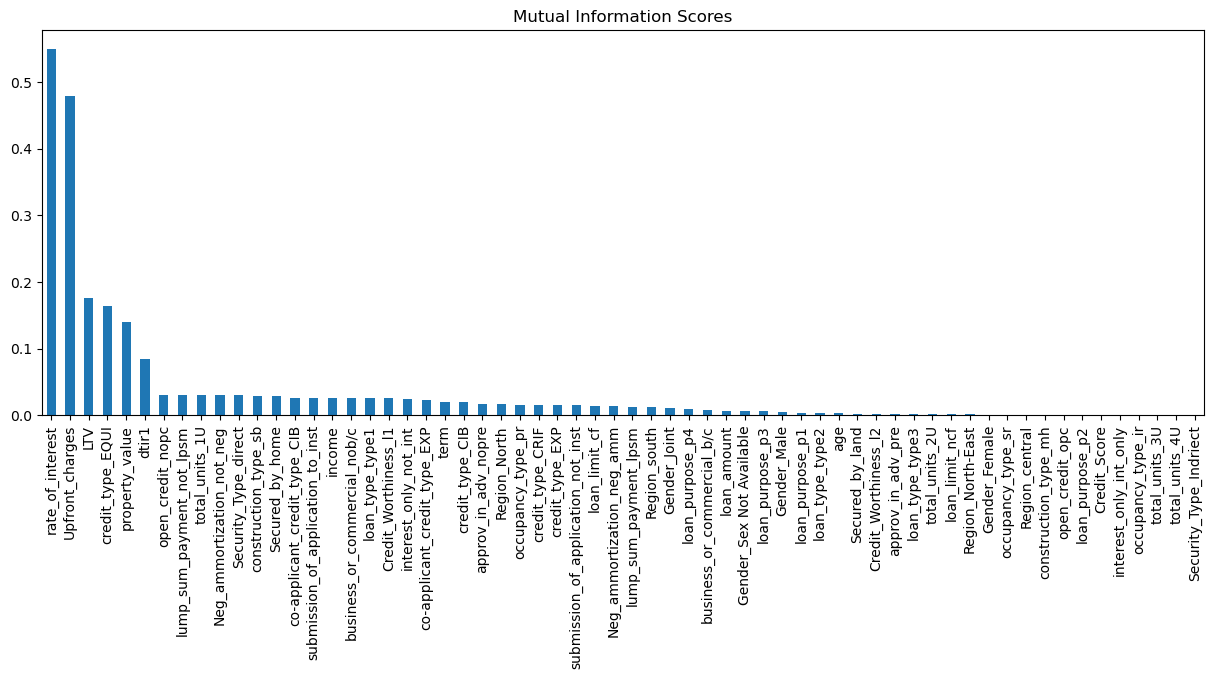

In [32]:
mi_scores.sort_values(ascending=False).plot(kind='bar', figsize=(15,5))
plt.title('Mutual Information Scores')
plt.show()

In [19]:
selected_features = mi_scores[mi_scores >= 0.01].index
df_final = df_pr[selected_features].copy()
df_final['Status'] = df_pr['Status']
df_final.shape

(148670, 35)

## Conclusions-Preprocessing:

-Suppression des variables ID, year et Interest_rate_spread.

-Imputation des valeurs manquantes : médiane pour les variables numériques et mode pour les variables catégorielles.

-Traitement des outliers sur LTV basé sur l’IQR.

-Encodage des variables catégorielles : Label Encoding pour age, One-Hot Encoding pour les autres variables catégorielles.

-Normalisation des variables numériques continues avec StandardScaler (8 variables concernées).

-Feature Selection avec Scores d'Information Mutuelle (MI): application d’un seuil à 0.01, permettant de sélectionner 35 variables sur 62.

La variable **rate_of_interest** a été supprimée malgré son score MI élevé car ses valeurs manquantes étaient uniquement présentes chez Status=1 
(data leakage partiel). Même après imputation ciblée, cette variable conserve une trace structurelle de la variable cible, ce qui biaiserait 
les modèles ML. 

Elle est donc exclue de la modélisation.

## Construction des modèles ML:

In [20]:
df_final = df_final.drop(columns=['rate_of_interest'])

X = df_final.drop(columns=['Status'])
y = df_final['Status']

#échantillonnage statifié: garantit que dans chaque partie (train et test) 
#nous aurons 75.4% de non défaut (Status=0) et 24.6% de (Statu=1); la même proportion que dans le dataset original.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


print(X_train.shape, X_test.shape)

(118936, 33) (29734, 33)


## Construction des modèles ML:

 ### Régression logistique:

In [21]:
lr = LogisticRegression(random_state=42, max_iter=2000, solver='saga')  #solver: optimisation utilisé pour trouver les meilleurs paramètres du modèle.
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print(classification_report(y_test, y_pred_lr))
print('AUC-ROC:', roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.86      0.99      0.92     22406
           1       0.93      0.50      0.65      7328

    accuracy                           0.87     29734
   macro avg       0.90      0.74      0.78     29734
weighted avg       0.88      0.87      0.85     29734

AUC-ROC: 0.8503788157472636


**Résultats du modèle:**

**-Status=0 (non défaut)** : F1-score = 0.92 → très bonne détection

**-Status= 1 (défaut)** : F1-score = 0.65 → performance plus faible

**-Recall (Status= 1 ) = 0.50**: le modèle ne détecte que 50% des vrais défauts (50% sont manqués)

**-AUC-ROC = 0.85** :bonne capacité globale de séparation des classes

### KNN:

In [22]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print(classification_report(y_test, y_pred_knn))
print('AUC-ROC:', roc_auc_score(y_test, knn.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.90      0.95      0.92     22406
           1       0.81      0.67      0.73      7328

    accuracy                           0.88     29734
   macro avg       0.86      0.81      0.83     29734
weighted avg       0.88      0.88      0.88     29734

AUC-ROC: 0.9087633020553212


Le modèle **KNN** présente des performances nettement supérieures à la régression logistique concernant la détection des défauts :

**-F1-score Status= 1 (défaut)** = **0.73** vs **0.65** pour la régression logistique 

**-Recall** (Status= 1)= **0.67** vs **0.50** pour la régression logistique 

**-AUC-ROC** = **0.90** vs **0.85**

### Decision Tree

In [23]:
dt = DecisionTreeClassifier(max_depth=5,random_state=42) 
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print(classification_report(y_test, y_pred_dt))
print('AUC-ROC:', roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     22406
           1       0.93      1.00      0.96      7328

    accuracy                           0.98     29734
   macro avg       0.97      0.99      0.98     29734
weighted avg       0.98      0.98      0.98     29734

AUC-ROC: 0.9942518832681669


In [40]:
print('Train score:', dt.score(X_train, y_train))
print('Test score:', dt.score(X_test, y_test))

Train score: 0.9815362884240264
Test score: 0.9814690253581758


### Random Forest:

In [24]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))
print('AUC-ROC:', roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     22406
           1       0.93      0.99      0.96      7328

    accuracy                           0.98     29734
   macro avg       0.97      0.98      0.97     29734
weighted avg       0.98      0.98      0.98     29734

AUC-ROC: 0.996020873059384


-Status=1 (cas de défaut) ***F1=0.96*** 

***AUC-ROC=0.996:*** modéle quasi parfait

-Similaire au Decision Tree mais AUC-ROC est bien meilleur

### SVM:

In [25]:
svm = CalibratedClassifierCV(LinearSVC(random_state=42, max_iter=2000))
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print(classification_report(y_test, y_pred_svm))
print('AUC-ROC:', roc_auc_score(y_test, svm.predict_proba(X_test)[:,1]))


              precision    recall  f1-score   support

           0       0.86      0.99      0.92     22406
           1       0.92      0.51      0.65      7328

    accuracy                           0.87     29734
   macro avg       0.89      0.75      0.79     29734
weighted avg       0.88      0.87      0.85     29734

AUC-ROC: 0.8491941905182132


***F1-score*** (Status=1; défaut) ***0.65*** performance proche de celle de la régression logistique.

***AUC-ROC = 0.84*** bonne capacité à distinguer les clients en défaut de ceux qui ne le sont pas, mais inférieure à celle des meilleurs modèles.

## Gradient Boosting:

In [26]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print(classification_report(y_test, y_pred_gb))
print('AUC-ROC:', roc_auc_score(y_test, gb.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     22406
           1       0.93      1.00      0.96      7328

    accuracy                           0.98     29734
   macro avg       0.97      0.99      0.98     29734
weighted avg       0.98      0.98      0.98     29734

AUC-ROC: 0.99665918388497


## XGBoost

In [27]:
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))
print('AUC-ROC:', roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     22406
           1       0.93      0.99      0.96      7328

    accuracy                           0.98     29734
   macro avg       0.96      0.98      0.97     29734
weighted avg       0.98      0.98      0.98     29734

AUC-ROC: 0.9966045433089312


### LightGBM

In [28]:
lgbm = LGBMClassifier(random_state=42)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)

print(classification_report(y_test, y_pred_lgbm))
print('AUC-ROC:', roc_auc_score(y_test, lgbm.predict_proba(X_test)[:,1]))

[LightGBM] [Info] Number of positive: 29311, number of negative: 89625
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009058 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1156
[LightGBM] [Info] Number of data points in the train set: 118936, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.246443 -> initscore=-1.117671
[LightGBM] [Info] Start training from score -1.117671
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     22406
           1       0.93      1.00      0.96      7328

    accuracy                           0.98     29734
   macro avg       0.97      0.99      0.98     29734
weighted avg       0.98      0.98      0.98     29734

AUC-ROC: 0.9969821367005562


### Naive Bayes

In [29]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print(classification_report(y_test, y_pred_nb))
print('AUC-ROC:', roc_auc_score(y_test, nb.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92     22406
           1       0.98      0.48      0.64      7328

    accuracy                           0.87     29734
   macro avg       0.92      0.74      0.78     29734
weighted avg       0.88      0.87      0.85     29734

AUC-ROC: 0.9776964190911901


#### Résultats du modèle Naive Bayes

-**F1-score (classe 1)** = **0.63** performance relativement faible sur la détection des défauts.

-**Recall (classe 1)** = **0.46** seulement 46 % des défauts réels sont détectés ; 54 % sont manqués.

-**AUC-ROC** = **0.97** excellente performance globale de classement des observations.

Bien que **Naive Bayes** obtienne une excellente AUC-ROC, ses performances sur la classe minoritaire restent limitées. Le modèle distingue globalement bien les observations, mais peine à identifier efficacement les cas de défaut, comme le montrent le F1-score et le recall de la classe 1.

### Extra Trees

In [30]:
et = ExtraTreesClassifier(random_state=42)
et.fit(X_train, y_train)
y_pred_et = et.predict(X_test)

print(classification_report(y_test, y_pred_et))
print('AUC-ROC:', roc_auc_score(y_test, et.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95     22406
           1       0.93      0.75      0.83      7328

    accuracy                           0.93     29734
   macro avg       0.93      0.87      0.89     29734
weighted avg       0.93      0.93      0.92     29734

AUC-ROC: 0.9791627708014111


### AdaBoost

In [31]:
ada = AdaBoostClassifier(random_state=42)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

print(classification_report(y_test, y_pred_ada))
print('AUC-ROC:', roc_auc_score(y_test, ada.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     22406
           1       0.93      1.00      0.96      7328

    accuracy                           0.98     29734
   macro avg       0.96      0.99      0.97     29734
weighted avg       0.98      0.98      0.98     29734

AUC-ROC: 0.9955556318352032


In [49]:
models = {
    'Decision Tree': (y_pred_dt, dt),
    'Random Forest': (y_pred_rf, rf),
    'LightGBM': (y_pred_lgbm, lgbm),
    'XGBoost': (y_pred_xgb, xgb),
    'Gradient Boosting': (y_pred_gb, gb),
    'Extra Trees': (y_pred_et, et),
    'KNN': (y_pred_knn, knn),
    'Naive Bayes': (y_pred_nb, nb),
    'SVM Linear': (y_pred_svm, svm),
    'Logistic Regression': (y_pred_lr, lr),
    'AdaBoost': (y_pred_ada, ada)
}

rows = []
for name, (y_pred, model) in models.items():
    report = classification_report(y_test, y_pred, output_dict=True)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    rows.append({
        'Modèle': name,
        'F1 classe 1': round(report['1']['f1-score'], 4),
        'AUC-ROC': round(auc, 4)
    })

df_results = pd.DataFrame(rows).sort_values('AUC-ROC', ascending=False)
print(df_results.to_string(index=False))

             Modèle  F1 classe 1  AUC-ROC
           LightGBM       0.9631   0.9970
  Gradient Boosting       0.9635   0.9967
            XGBoost       0.9594   0.9966
      Random Forest       0.9608   0.9960
           AdaBoost       0.9613   0.9956
      Decision Tree       0.9637   0.9943
        Extra Trees       0.8333   0.9792
        Naive Bayes       0.6446   0.9777
                KNN       0.7342   0.9088
Logistic Regression       0.6494   0.8504
         SVM Linear       0.6544   0.8492


### Conclusion:
À l’issue de la phase d’évaluation, trois modèles ont été retenus pour le tuning:

-**LightGBM** (AUC-ROC : 0.997, F1 classe 1 : 0.963) 

-**Gradient Boosting** (AUC-ROC : 0.997, F1 classe 1 : 0.964)

-**Random Forest** (AUC-ROC : 0.996, F1 classe 1 : 0.961)

Ces modèles ont été sélectionnés sur la base de leur **AUC-ROC** et **F1-score**  sur la classe minoritaire (défaut).

L’optimisation des hyperparamètres sera réalisée à l’aide de **RandomizedSearchCV**, une méthode permettant d’explorer efficacement l’espace des paramètres tout en limitant le coût computationnel. Cette approche vise à améliorer les performances prédictives des modèles tout en réduisant le risque de *l'overfitting*.

## Tuning:

#### LIGHTGBM

In [32]:
param_grid_lgbm = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [20, 31, 50, 100],
    'min_child_samples': [10, 20, 50]
}

lgbm_tuned = LGBMClassifier(random_state=42)

rs_lgbm = RandomizedSearchCV(
    lgbm_tuned, 
    param_grid_lgbm, 
    n_iter=20, 
    cv=5, 
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1)

rs_lgbm.fit(X_train, y_train)
print('Meilleurs paramètres:', rs_lgbm.best_params_)
print('Meilleur AUC-ROC CV:', rs_lgbm.best_score_)

[LightGBM] [Info] Number of positive: 29311, number of negative: 89625
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.030547 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1150
[LightGBM] [Info] Number of data points in the train set: 118936, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.246443 -> initscore=-1.117671
[LightGBM] [Info] Start training from score -1.117671
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Meilleurs paramètres: {'num_leaves': 20, 'n_estimators': 200, 'min_child_samples': 50, 'max_depth': 7, 'learning_rate': 0.05}
Meilleur AUC-ROC CV: 0.9969814631488625


In [33]:
lgbm_best = rs_lgbm.best_estimator_
y_pred_lgbm_tuned = lgbm_best.predict(X_test)

print('APRÈS TUNING=')
print(classification_report(y_test, y_pred_lgbm_tuned))
print('AUC-ROC:', roc_auc_score(y_test, lgbm_best.predict_proba(X_test)[:,1]))

APRÈS TUNING=
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     22406
           1       0.93      1.00      0.96      7328

    accuracy                           0.98     29734
   macro avg       0.97      0.99      0.98     29734
weighted avg       0.98      0.98      0.98     29734

AUC-ROC: 0.9970098269841164


In [34]:
print('Train AUC-ROC:', roc_auc_score(y_train, lgbm_best.predict_proba(X_train)[:,1]))
print('Test AUC-ROC:', roc_auc_score(y_test, lgbm_best.predict_proba(X_test)[:,1]))

Train AUC-ROC: 0.9976127309176581
Test AUC-ROC: 0.9970098269841164


#### Tuning de Gradient Boosting:

In [35]:
param_grid_gb = {'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.8, 0.9, 1.0]}

gb_tuned = GradientBoostingClassifier(random_state=42)

rs_gb = RandomizedSearchCV(
    gb_tuned,
    param_grid_gb,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1)

rs_gb.fit(X_train, y_train)
print('Meilleurs paramètres:', rs_gb.best_params_)
print('Meilleur AUC-ROC CV:', rs_gb.best_score_)

Meilleurs paramètres: {'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 10, 'max_depth': 5, 'learning_rate': 0.05}
Meilleur AUC-ROC CV: 0.9970416385220956


In [40]:
gb_best = rs_gb.best_estimator_
y_pred_gb_tuned = gb_best.predict(X_test)

print('APRÈS TUNING')
print(classification_report(y_test, y_pred_gb_tuned))
print('AUC-ROC:', roc_auc_score(y_test, gb_best.predict_proba(X_test)[:,1]))
print('Train AUC-ROC:', roc_auc_score(y_train, gb_best.predict_proba(X_train)[:,1]))

APRÈS TUNING
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     22406
           1       0.93      1.00      0.96      7328

    accuracy                           0.98     29734
   macro avg       0.96      0.99      0.98     29734
weighted avg       0.98      0.98      0.98     29734

AUC-ROC: 0.9969866588682773
Train AUC-ROC: 0.9978527266884968


#### Tuning Random Forest: 

In [36]:
param_grid_rf = {'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_tuned = RandomForestClassifier(random_state=42)

rs_rf = RandomizedSearchCV(
    rf_tuned,
    param_grid_rf,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

rs_rf.fit(X_train, y_train)
print('Meilleurs paramètres:', rs_rf.best_params_)
print('Meilleur AUC-ROC CV:', rs_rf.best_score_)

Meilleurs paramètres: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 15}
Meilleur AUC-ROC CV: 0.9968218070684483


In [37]:
rf_best = rs_rf.best_estimator_
y_pred_rf_tuned = rf_best.predict(X_test)

print('APRÈS TUNING')
print(classification_report(y_test, y_pred_rf_tuned))
print('AUC-ROC test:', roc_auc_score(y_test, rf_best.predict_proba(X_test)[:,1]))
print('Train AUC-ROC:', roc_auc_score(y_train, rf_best.predict_proba(X_train)[:,1]))

APRÈS TUNING
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     22406
           1       0.93      1.00      0.96      7328

    accuracy                           0.98     29734
   macro avg       0.97      0.99      0.98     29734
weighted avg       0.98      0.98      0.98     29734

AUC-ROC test: 0.9968315652642169
Train AUC-ROC: 0.9981266295986955


In [38]:
 roc_auc_score(y_train, rf_best.predict_proba(X_train)[:,1])

0.9981266295986955

In [39]:
comparison = {
    'Modèle': ['LightGBM', 'Gradient Boosting', 'Random Forest'],
    'AUC-ROC avant': [0.9970, 0.9967, 0.9960],
    'AUC-ROC après': [
        roc_auc_score(y_test, lgbm_best.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, gb_best.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, rf_best.predict_proba(X_test)[:,1])
    ]
}

df_comparison = pd.DataFrame(comparison)
print(df_comparison)

NameError: name 'gb_best' is not defined

##### Le tuning n'a pas apporté de gains significatifs car les modèles  étaient déjà très performants avec les paramètres par défaut.Cela confirme la bonne qualité du preprocessing effectué.

## Choix du modèle final : Random Forest

Les trois modèles candidats (LightGBM, Gradient Boosting, Random Forest) présentent des performances quasi identiques après tuning (AUC-ROC ≈ 0.997, 
F1 classe 1 ≈ 0.96). 

Le choix de Random Forest comme modèle final repose sur les critères suivants :

- Robustesse et stabilité reconnues
  
- Moins sensible aux hyperparamètres

  
- Fiabilité dans le contexte bancaire où la confiance est essentielle

  
- Absence d'overfitting confirmée (Train/Test ≈ 0.0016 de différence)

In [35]:
#sauvegarde du modèle:
rf_best = rs_rf.best_estimator_
joblib.dump(rf_best, 'model_rf.pkl')

['model_rf.pkl']

In [64]:
#joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [67]:
import os
print(os.getcwd())

C:\Users\souri


In [29]:
#Le scaler du début a été crée avant la feature selection: 
num_cols_final = ['Upfront_charges', 'property_value', 'income', 'LTV', 'dtir1']
scaler_final = StandardScaler()
scaler_final.fit(X_train[num_cols_final])
joblib.dump(scaler_final, 'scaler.pkl')

['scaler.pkl']